# Calibration Summary

Summarize empirical null calibration results across datasets:
- NTC null distribution diagnostics (z-value histograms, Q-Q plots)
- Number of significant hits at various FDR thresholds
- Direct target repression with calibrated p-values
- Cis vs trans breakdown

**Input:** Calibrated results from `calibrate.py` (per-dataset `calibration/` dirs)  
**Output:** Combined summary tables and diagnostic plots

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
# Project root
PROJECT_ROOT = Path("/cellar/users/aklie/data/datasets/tf_perturb_seq")

sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_colors")
dataset_order = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_order")

In [3]:
# Paths
RUN_LABEL = "cleanser_unified"
BASE_DIR = PROJECT_ROOT / "datasets" / "technology-benchmark_WTC11_TF-Perturb-seq"
OUTPUT_DIR = BASE_DIR / "results" / "cross_tech_comparison" / RUN_LABEL / "inference"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS_ROOT = PROJECT_ROOT / "datasets"

# Dataset list
DATASETS = [
    "Hon_WTC11-benchmark_TF-Perturb-seq",
    "Huangfu_WTC11-benchmark_TF-Perturb-seq",
    "Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3",
    "Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2",
    "Engreitz_WTC11-benchmark_TF-Perturb-seq",
]

SUFFIX = "_WTC11-benchmark_TF-Perturb-seq"
def short_name(ds):
    return ds.replace(SUFFIX, "").replace("_", " ")

print(f"Run label: {RUN_LABEL}")
print(f"Output directory: {OUTPUT_DIR}")

Run label: cleanser_unified
Output directory: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified/inference


In [4]:
# Load all calibrated results
all_results = {}
direct_target_results = {}

for ds in DATASETS:
    cal_dir = DATASETS_ROOT / ds / "runs" / RUN_LABEL / "calibration"
    
    all_path = cal_dir / f"{ds}_calibrated_all_results.tsv"
    dt_path = cal_dir / f"{ds}_calibrated_direct_target_results.tsv"
    
    if all_path.exists():
        all_results[ds] = pd.read_csv(all_path, sep="\t", low_memory=False)
        all_results[ds]["dataset"] = ds
        print(f"  {ds}: {len(all_results[ds]):,} rows")
    else:
        print(f"  {ds}: MISSING {all_path}")
    
    if dt_path.exists():
        direct_target_results[ds] = pd.read_csv(dt_path, sep="\t", low_memory=False)
        direct_target_results[ds]["dataset"] = ds

print(f"\nLoaded {len(all_results)} datasets")

  Hon_WTC11-benchmark_TF-Perturb-seq: 692,122 rows
  Huangfu_WTC11-benchmark_TF-Perturb-seq: 620,638 rows
  Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3: 1,008,546 rows
  Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2: 947,570 rows
  Engreitz_WTC11-benchmark_TF-Perturb-seq: 362,452 rows

Loaded 5 datasets


## NTC Null Distribution Diagnostics

For each dataset, plot the z-value distribution of NTC elements (the empirical null) overlaid with the fitted t-distribution.

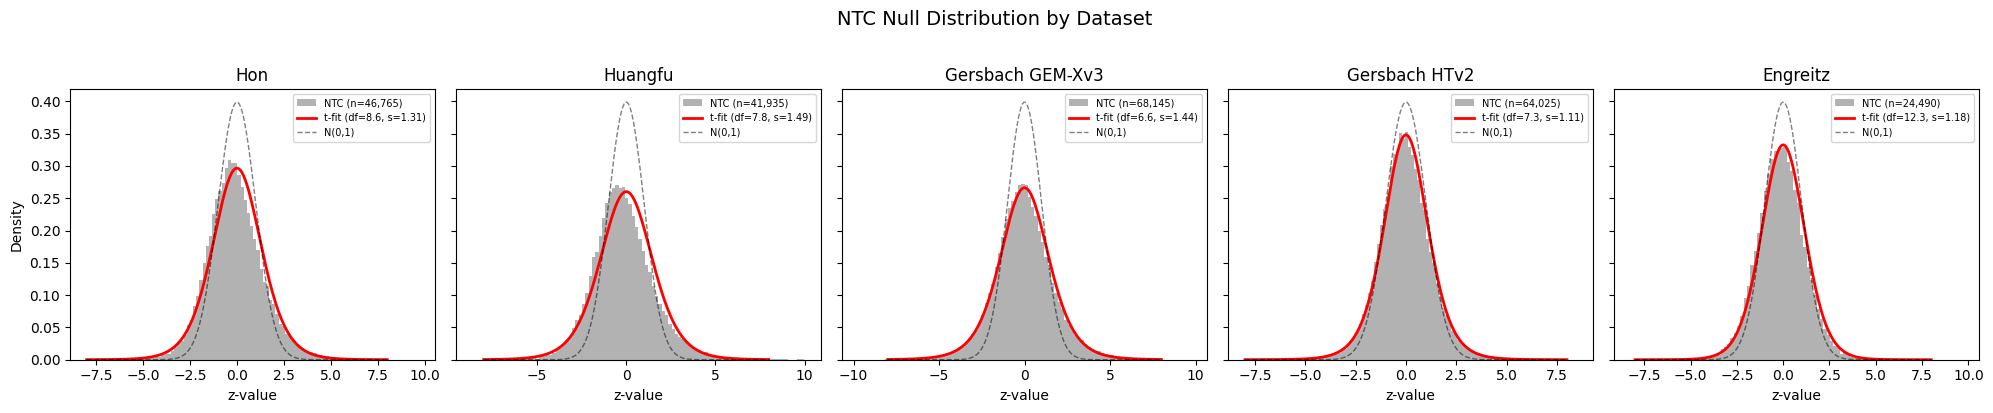

In [5]:
from scipy import stats

n_ds = len(all_results)
fig, axes = plt.subplots(1, n_ds, figsize=(4 * n_ds, 4), sharey=True)

for ax, ds in zip(axes, dataset_order):
    if ds not in all_results:
        ax.set_title(short_name(ds) + "\n(missing)")
        continue
    
    df = all_results[ds]
    
    # Compute z-values
    valid = df["log2fc_se"].notna() & (df["log2fc_se"] > 0)
    df_valid = df[valid].copy()
    df_valid["z_value"] = df_valid["log2fc"] / df_valid["log2fc_se"]
    
    # NTC vs targeting
    ntc = df_valid[df_valid["element_label"].str.lower().str.replace("-", "_") == "non_targeting"]
    targeting = df_valid[df_valid["element_label"].str.lower().str.replace("-", "_") != "non_targeting"]
    
    # Plot NTC histogram
    z_ntc = ntc["z_value"].dropna().values
    z_ntc_clipped = z_ntc[(z_ntc > -10) & (z_ntc < 10)]
    ax.hist(z_ntc_clipped, bins=100, density=True, alpha=0.6, color="gray", label=f"NTC (n={len(z_ntc):,})")
    
    # Fit t-distribution
    if len(z_ntc) > 100:
        df_hat, _, scale_hat = stats.t.fit(z_ntc, floc=0.0)
        x = np.linspace(-8, 8, 200)
        ax.plot(x, stats.t.pdf(x, df_hat, loc=0, scale=scale_hat), "r-", lw=2,
                label=f"t-fit (df={df_hat:.1f}, s={scale_hat:.2f})")
    
    # Standard normal for reference
    ax.plot(x, stats.norm.pdf(x), "k--", lw=1, alpha=0.5, label="N(0,1)")
    
    ax.set_title(short_name(ds))
    ax.set_xlabel("z-value")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Density")
fig.suptitle("NTC Null Distribution by Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ntc_null_distributions.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Significant Hits Summary

Count significant tests at various FDR thresholds, broken down by direct target, cis, and trans.

In [6]:
# Build summary table
summary_rows = []
for ds in dataset_order:
    if ds not in all_results:
        continue
    df = all_results[ds]
    targeting = df[df["element_label"].str.lower().str.replace("-", "_") != "non_targeting"]
    
    for fdr in [0.01, 0.05, 0.10, 0.20]:
        sig = targeting[targeting["empirical_pval_adj"] < fdr]
        summary_rows.append({
            "dataset": ds,
            "fdr_threshold": fdr,
            "n_total_tests": len(targeting),
            "n_significant": len(sig),
            "n_sig_direct_target": sig["is_direct_target"].sum(),
            "n_sig_cis": sig["is_cis"].sum(),
            "n_sig_trans": (~sig["is_cis"]).sum(),
            "n_elements_with_hits": sig["element_id"].nunique(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_df["dataset"] = pd.Categorical(summary_df["dataset"], categories=dataset_order, ordered=True)
summary_df = summary_df.sort_values(["dataset", "fdr_threshold"])

# Save
summary_df.to_csv(OUTPUT_DIR / "calibration_summary.tsv", sep="\t", index=False)
summary_df

,dataset,fdr_threshold,n_total_tests,n_significant,n_sig_direct_target,n_sig_cis,n_sig_trans,n_elements_with_hits
0,Hon_WTC11-benchmark_TF-Perturb-seq,0.01,645357,654,25,26,628,52
1,Hon_WTC11-benchmark_TF-Perturb-seq,0.05,645357,1380,31,32,1348,61
2,Hon_WTC11-benchmark_TF-Perturb-seq,0.10,645357,2151,32,34,2117,66
3,Hon_WTC11-benchmark_TF-Perturb-seq,0.20,645357,3555,32,34,3521,67
4,Huangfu_WTC11-benchmark_TF-Perturb-seq,0.01,578703,1064,27,27,1037,59
5,Huangfu_WTC11-benchmark_TF-Perturb-seq,0.05,578703,2545,29,30,2515,65
6,Huangfu_WTC11-benchmark_TF-Perturb-seq,0.10,578703,4199,31,32,4167,69
7,Huangfu_WTC11-benchmark_TF-Perturb-seq,0.20,578703,7437,33,34,7403,69
8,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,0.01,940401,1009,35,36,973,51
9,Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3,0.05,940401,2006,37,38,1968,57


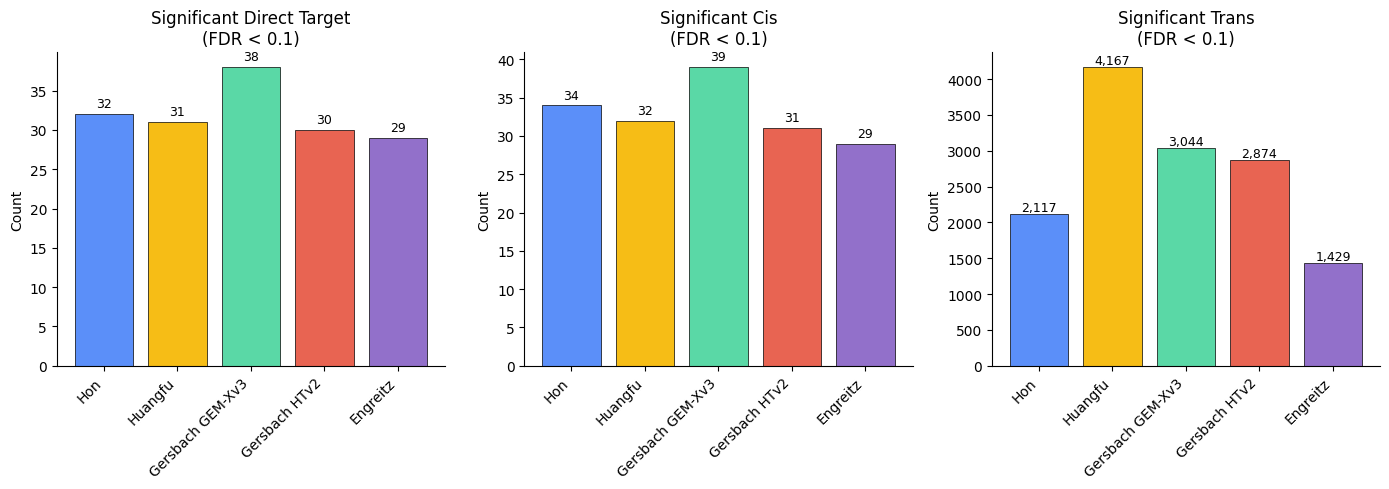

In [7]:
# Barplot: significant hits at FDR < 0.10 by category
fdr_cut = 0.10
plot_df = summary_df[summary_df["fdr_threshold"] == fdr_cut].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (col, title) in zip(axes, [
    ("n_sig_direct_target", "Significant Direct Target"),
    ("n_sig_cis", "Significant Cis"),
    ("n_sig_trans", "Significant Trans"),
]):
    colors = [dataset_colors.get(ds, "gray") for ds in plot_df["dataset"]]
    bars = ax.bar(range(len(plot_df)), plot_df[col], color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels([short_name(ds) for ds in plot_df["dataset"]], rotation=45, ha="right")
    ax.set_ylabel("Count")
    ax.set_title(f"{title}\n(FDR < {fdr_cut})")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    for i, v in enumerate(plot_df[col]):
        ax.text(i, v + 0.5, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "significant_hits_by_category.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Direct Target Repression (Calibrated)

Compare intended target knockdown across datasets using calibrated empirical p-values.

In [8]:
# Combine direct target results
dt_combined = pd.concat(direct_target_results.values(), ignore_index=True)
dt_combined["dataset"] = pd.Categorical(dt_combined["dataset"], categories=dataset_order, ordered=True)
dt_combined["lab"] = dt_combined["dataset"].astype(str).apply(short_name)
dt_combined["fc"] = 2 ** dt_combined["log2fc"]

# Save
dt_combined.to_csv(OUTPUT_DIR / "combined_calibrated_direct_target_results.tsv", sep="\t", index=False)
print(f"Combined direct target results: {len(dt_combined)} rows across {dt_combined['dataset'].nunique()} datasets")
dt_combined.head()

Combined direct target results: 235 rows across 5 datasets


,element_id,element_symbol,element_label,tested_gene_id,tested_gene_symbol,n_cells,log2fc,log2fc_se,is_cis,is_direct_target,posterior_pval,empirical_pval,empirical_pval_adj,dataset,lab,fc
0,ENSG00000005339|chr16:3880184-3880693,CREBBP,targeting,ENSG00000005339,CREBBP,1197,-0.602720,0.083588,True,True,5.568835e-13,0.000017,0.014598,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,0.658511
1,ENSG00000008083|chr6:15245952-15246085,JARID2,targeting,ENSG00000008083,JARID2,800,-0.066924,0.055434,True,True,2.273268e-01,0.391664,1.000000,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,0.954671
2,ENSG00000049618|chr6:156777663-156778009,ARID1B,targeting,ENSG00000049618,ARID1B,1543,-0.096963,0.055295,True,True,7.950503e-02,0.216781,1.000000,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,0.934999
3,ENSG00000049618|chr6:156779041-156779230,ARID1B,targeting,ENSG00000049618,ARID1B,1624,-0.117909,0.059492,True,True,4.748692e-02,0.164317,1.000000,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,0.921522
4,ENSG00000066117|chr12:50085236-50085698,SMARCD1,targeting,ENSG00000066117,SMARCD1,1011,-0.682992,0.089256,True,True,1.978273e-14,0.000007,0.007819,Hon_WTC11-benchmark_TF-Perturb-seq,Hon,0.622872


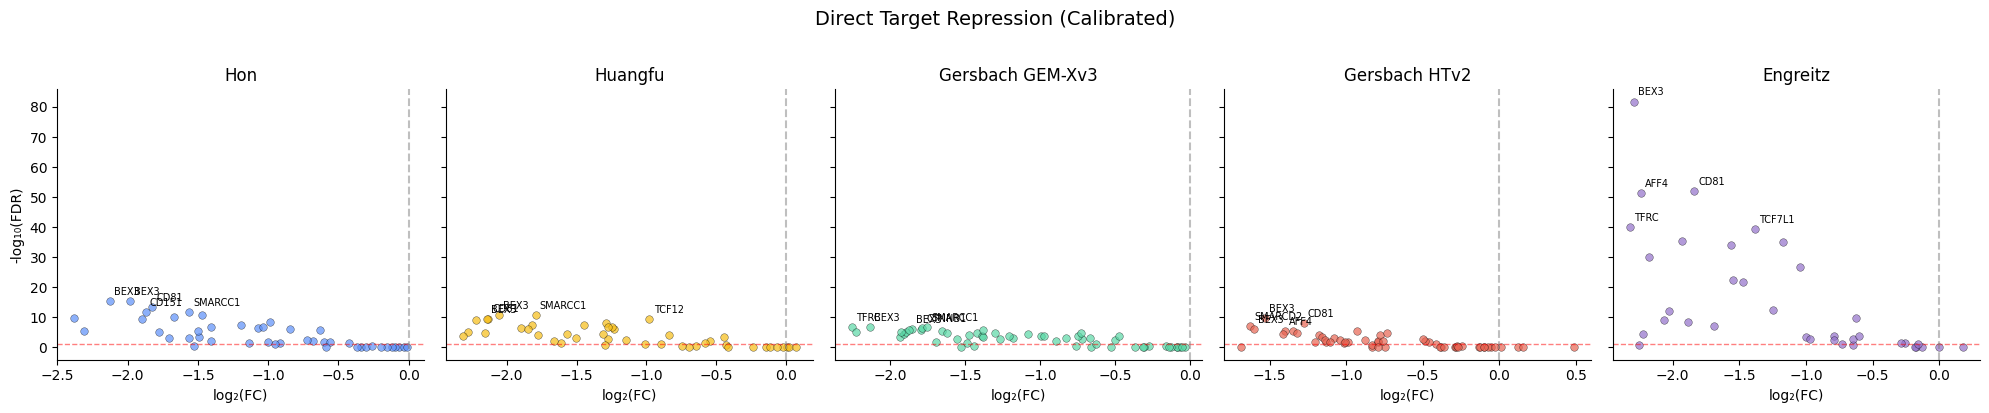

In [9]:
# Volcano-style: log2FC vs -log10(empirical_pval_adj) per dataset
fig, axes = plt.subplots(1, len(dataset_order), figsize=(4 * len(dataset_order), 4), sharey=True)

for ax, ds in zip(axes, dataset_order):
    if ds not in direct_target_results:
        ax.set_title(short_name(ds) + "\n(missing)")
        continue
    
    dt = direct_target_results[ds]
    dt = dt[dt["empirical_pval_adj"].notna()].copy()
    dt["-log10_padj"] = -np.log10(dt["empirical_pval_adj"] + 1e-300)
    
    color = dataset_colors.get(ds, "gray")
    ax.scatter(dt["log2fc"], dt["-log10_padj"], s=30, alpha=0.7, color=color, edgecolor="black", linewidth=0.3)
    
    # Label top hits
    top = dt.nsmallest(5, "empirical_pval_adj")
    for _, row in top.iterrows():
        ax.annotate(row["element_symbol"], (row["log2fc"], row["-log10_padj"]),
                    fontsize=7, ha="left", va="bottom", xytext=(3, 3), textcoords="offset points")
    
    ax.axhline(-np.log10(0.10), color="red", linestyle="--", alpha=0.5, linewidth=1)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("log₂(FC)")
    ax.set_title(short_name(ds))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("-log₁₀(FDR)")
fig.suptitle("Direct Target Repression (Calibrated)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direct_target_volcano.pdf", dpi=300, bbox_inches="tight")
plt.show()

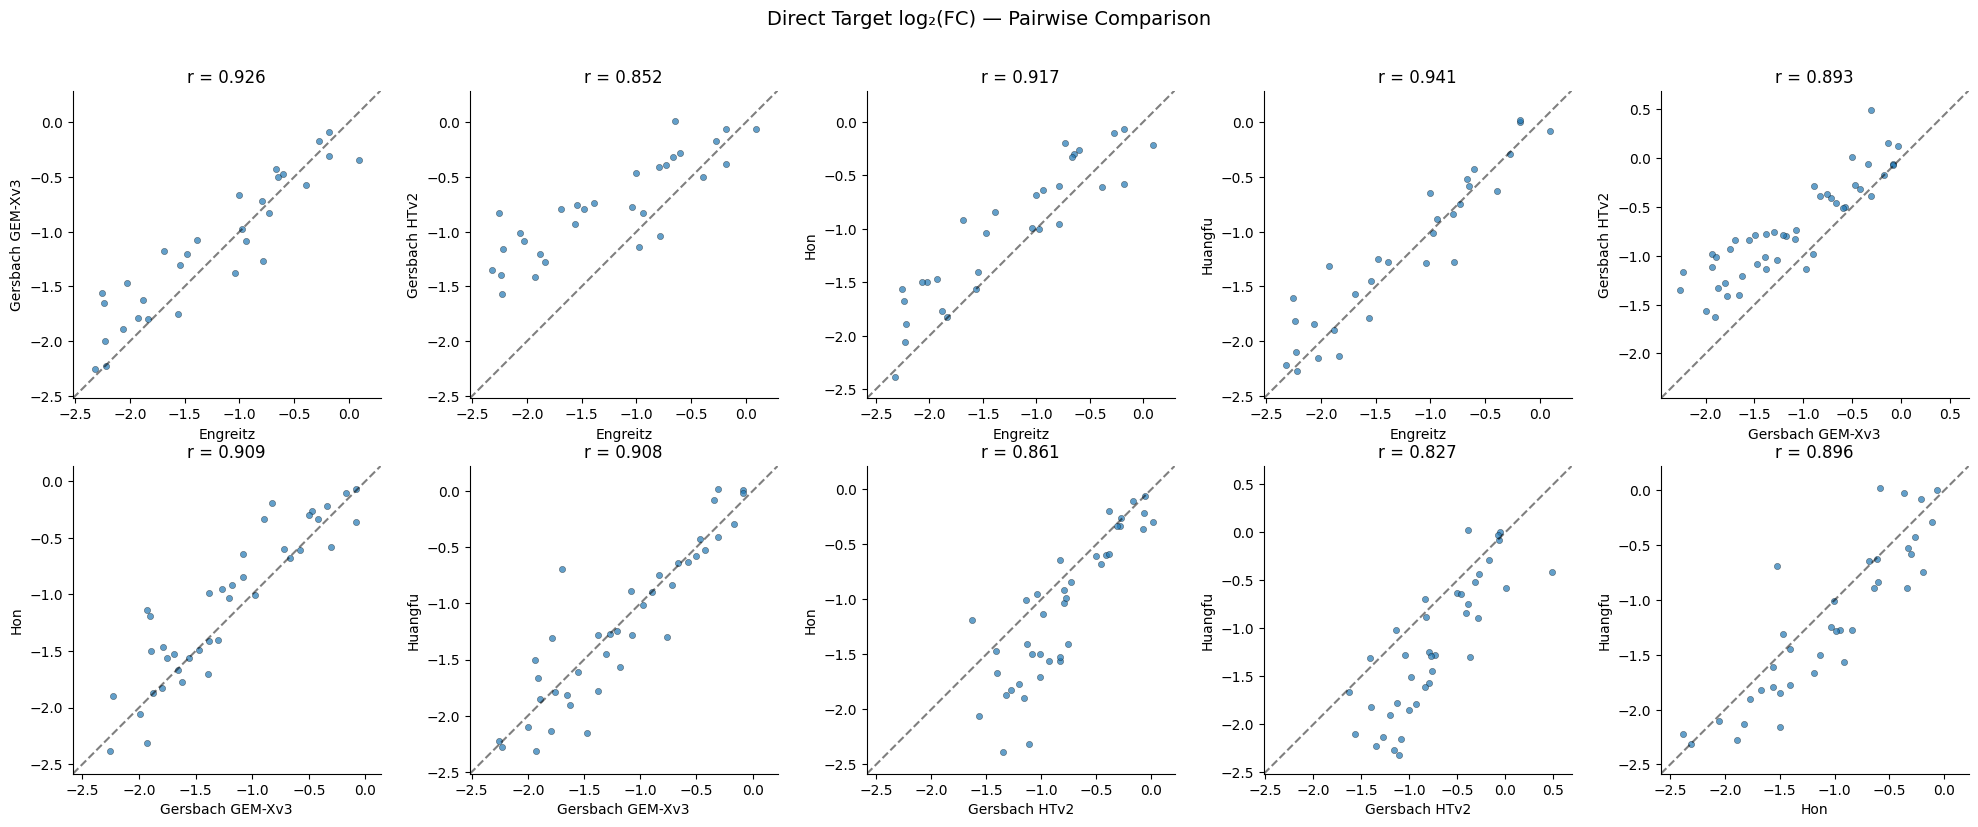

In [10]:
# Pairwise scatter of direct target log2FC across datasets
from itertools import combinations

# Pivot to element × dataset matrix
dt_pivot = dt_combined.pivot_table(index="element_symbol", columns="lab", values="log2fc", aggfunc="mean")

pairs = list(combinations(dt_pivot.columns, 2))
n_pairs = len(pairs)
ncols = min(n_pairs, 5)
nrows = (n_pairs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes).ravel()

for idx, (ds1, ds2) in enumerate(pairs):
    ax = axes[idx]
    valid = dt_pivot[[ds1, ds2]].dropna()
    if len(valid) < 3:
        ax.set_title(f"{ds1} vs {ds2}\n(insufficient data)")
        continue
    
    r = valid[ds1].corr(valid[ds2])
    ax.scatter(valid[ds1], valid[ds2], s=20, alpha=0.7, edgecolor="black", linewidth=0.3)
    
    lo = min(valid[ds1].min(), valid[ds2].min()) - 0.2
    hi = max(valid[ds1].max(), valid[ds2].max()) + 0.2
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.5)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel(ds1)
    ax.set_ylabel(ds2)
    ax.set_title(f"r = {r:.3f}")
    ax.set_aspect("equal")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Hide unused axes
for idx in range(n_pairs, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Direct Target log₂(FC) — Pairwise Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direct_target_pairwise_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Direct Target FC Boxplot

Fold change distribution for positive controls and targeting elements across datasets.

/tmp/ipykernel_2089556/2163163201.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = pos_ctrl.groupby("dataset")["fc"].median().reindex(dataset_order)


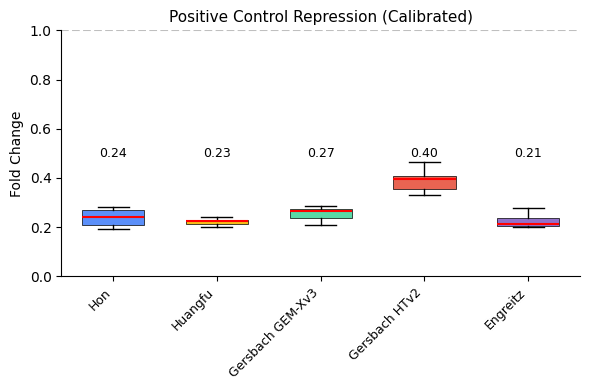

In [11]:
# Boxplot of FC for positive controls
pos_ctrl = dt_combined[dt_combined["element_label"] == "positive control"].copy()

fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot(
    [pos_ctrl[pos_ctrl["dataset"] == ds]["fc"].dropna() for ds in dataset_order],
    positions=range(len(dataset_order)),
    widths=0.6,
    patch_artist=True,
    medianprops=dict(color="red", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker=".", markersize=3, markerfacecolor="black", markeredgecolor="none"),
)

for patch, ds in zip(bp["boxes"], dataset_order):
    patch.set_facecolor(dataset_colors[ds])
    patch.set_edgecolor("black")
    patch.set_linewidth(0.5)

medians = pos_ctrl.groupby("dataset")["fc"].median().reindex(dataset_order)
ymax = pos_ctrl["fc"].max()
for i, (ds, med) in enumerate(medians.items()):
    ax.text(i, ymax * 1.02, f"{med:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(range(len(dataset_order)))
ax.set_xticklabels([short_name(ds) for ds in dataset_order], fontsize=9, rotation=45, ha="right")
ax.set_ylabel("Fold Change", fontsize=10)
ax.set_title("Positive Control Repression (Calibrated)", fontsize=11)
ax.set_ylim(0, 1)
ax.axhline(1, color="gray", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direct_target_fc_boxplot.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Pairwise Scatter Grid with Correlation Heatmap

Lower-triangle scatter grid colored by Pearson r, with colored dataset label strips.

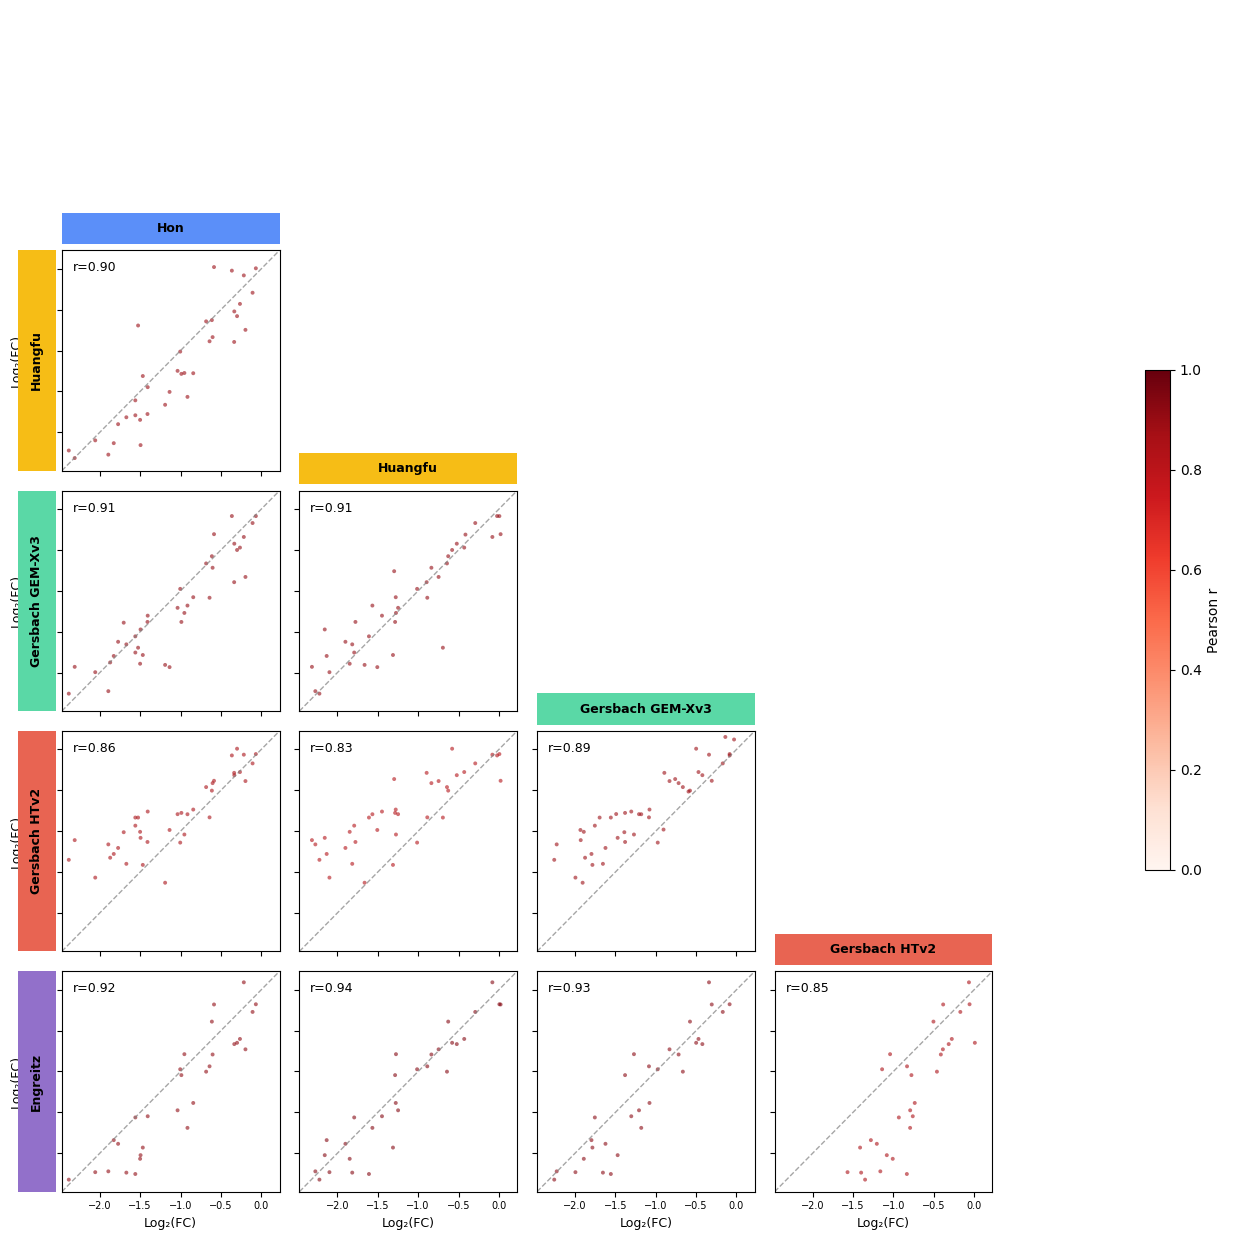

In [12]:
from matplotlib.patches import Rectangle

# Build pairwise data from the pivot table
lab_order = [short_name(ds) for ds in dataset_order]
dt_pivot_ordered = dt_pivot.reindex(columns=lab_order)

pair_data = {}
n = len(lab_order)

for i in range(n):
    for j in range(n):
        if i <= j:
            continue
        d1 = dt_pivot_ordered.iloc[:, j].rename("x")
        d2 = dt_pivot_ordered.iloc[:, i].rename("y")
        m = pd.concat([d1, d2], axis=1).dropna()
        r = np.corrcoef(m["x"], m["y"])[0, 1] if len(m) > 2 else np.nan
        pair_data[(i, j)] = {"df": m, "r": r}

# Global limits
all_vals = np.concatenate([v["df"][["x", "y"]].to_numpy().ravel() for v in pair_data.values() if not v["df"].empty])
lo, hi = np.nanpercentile(all_vals, [0.5, 99.5])
pad = 0.05 * (hi - lo)
lo -= pad
hi += pad

# Draw grid
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cmap = plt.cm.Reds

fig, axes = plt.subplots(n, n, figsize=(2.5 * n, 2.5 * n))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i <= j:
            ax.set_axis_off()
            continue

        entry = pair_data[(i, j)]
        m = entry["df"]
        r = entry["r"]

        point_color = cmap(norm(np.clip(r, 0, 1))) if not np.isnan(r) else "gray"

        if not m.empty:
            ax.scatter(m["x"], m["y"], s=8, alpha=0.6, edgecolor="none", color=point_color)

        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1, color="gray", alpha=0.7)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        if not np.isnan(r):
            ax.text(0.05, 0.95, f"r={r:.2f}", transform=ax.transAxes, va="top", ha="left", fontsize=9)

        if i == n - 1:
            ax.set_xlabel("Log₂(FC)", fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel("Log₂(FC)", fontsize=9)
        else:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=7)

plt.tight_layout()

# Colored label strips
for j in range(n - 1):
    ax = axes[j + 1, j]
    bbox = ax.get_position()
    rect = fig.add_axes([bbox.x0, bbox.y1 + 0.005, bbox.width, 0.025])
    rect.set_xlim(0, 1); rect.set_ylim(0, 1)
    rect.add_patch(Rectangle((0, 0), 1, 1, facecolor=dataset_colors[dataset_order[j]], edgecolor="none"))
    rect.text(0.5, 0.5, lab_order[j], ha="center", va="center", fontsize=9, fontweight="bold")
    rect.axis("off")

for i in range(1, n):
    ax = axes[i, 0]
    bbox = ax.get_position()
    rect = fig.add_axes([bbox.x0 - 0.035, bbox.y0, 0.03, bbox.height])
    rect.set_xlim(0, 1); rect.set_ylim(0, 1)
    rect.add_patch(Rectangle((0, 0), 1, 1, facecolor=dataset_colors[dataset_order[i]], edgecolor="none"))
    rect.text(0.5, 0.5, lab_order[i], ha="center", va="center", fontsize=9, fontweight="bold", rotation=90)
    rect.axis("off")

# Colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Pearson r", fontsize=10)

plt.savefig(OUTPUT_DIR / "direct_target_correlation_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

---

# DONE!